In [16]:
import pandas as pd
import json
import sys
from pathlib import Path
from utils import *
import joblib
from utils.helper_classification import *
# add the directory to the path
sys.path.insert(0, str(Path.cwd()))

In [17]:
pred1 = pd.read_excel('mlef_pipeline/results/OS_24/C23/RWD_DP_PYRAD/prediction_CV.xlsx')
pred2=pd.read_excel('/home/cristina/I3LUNG_PDSS/train_set_predictions_IL-6057.xlsx')


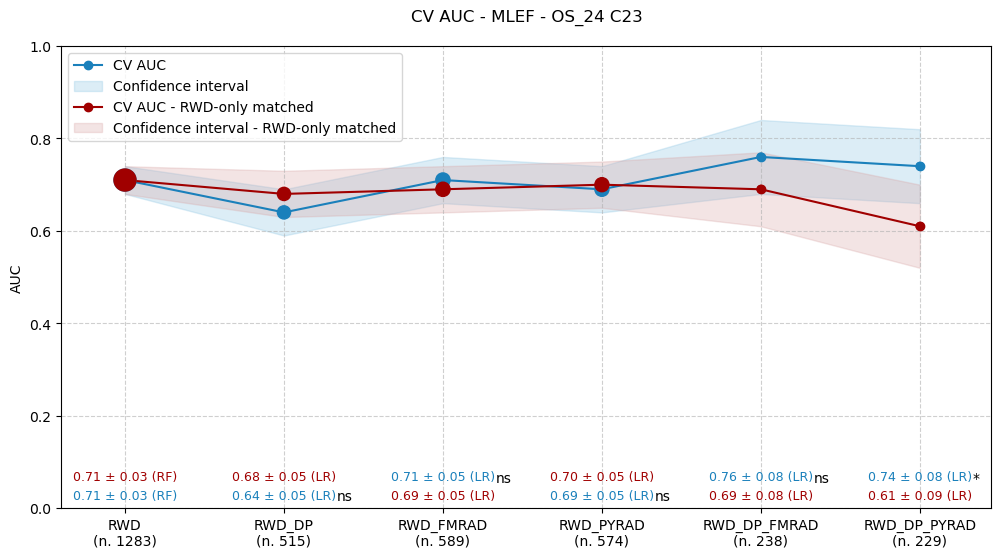

In [2]:
plot_auc_results(
    architecture="MLEF",
    outcome="OS_24",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

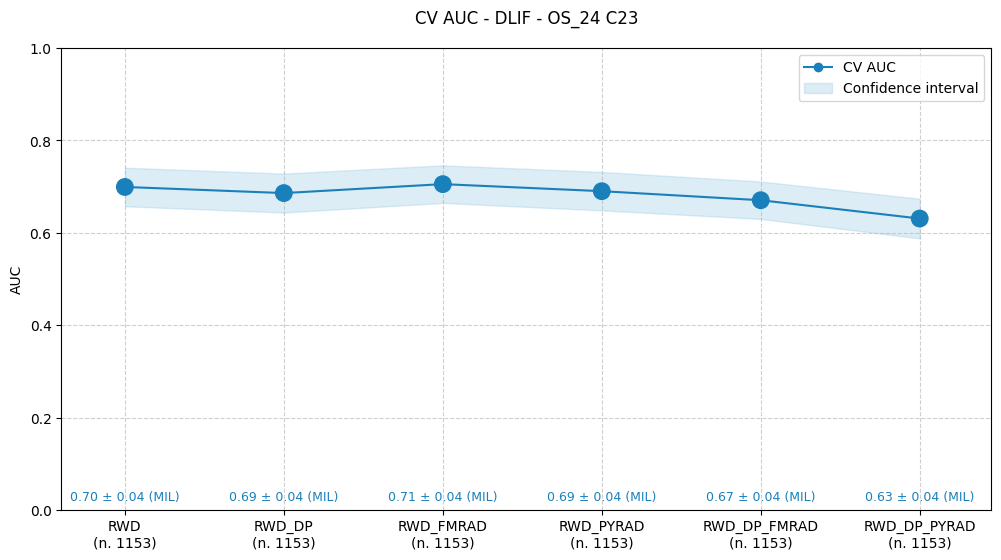

In [3]:
plot_auc_results(
    architecture="DLIF",
    outcome="OS_24",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

# BIOMARKER COMPARISON SPIDER PLOT

Thresholds used to calculate biomarkers: (biomarker >= threshold will be convert into class 1)
- PDL1: 
    - 1 for OS 6, DCR (PDL1 >= 1%); 2 for OS 24 (PDL1 >= 50%)
- NLR: 4
- LDH: 400
- ECOG: 2

Take the real values of the biomarker, remove the missing ones.
According to the outcome (DCR/OS6/OS24) the biomarker will be converted into TP, FP, TN, FN.
Then calculate AUC, accuracy, sensitivity, specificity using as y_true the outcome and y_pred the biomarker.
On the same subset of patients, for each biomarker, use the model to compute the metrics

In [19]:
rwd = pd.read_csv('data/rwd.csv')
outcome = 'OS_24' #or 'OS_6' or 'DCR'
outcomes = pd.read_csv('data/outcomes.csv')
rwd = rwd.merge(outcomes, on='Subject', how='inner')
with open('mlef_pipeline/split.json', 'r') as f:
    split = json.load(f)
test = rwd[rwd['Subject'].isin(split['TEST_SET'])]
test = test[test[outcome].notna()].reset_index(drop=True)
y_pred_mlef = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/prediction_test.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/rwd.csv'

In [ ]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

,BIO_PDL1_50,binary_BIO_PDL1_50,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
0,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
1,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
2,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
3,TN,0.0,FP,1.0,FP,1.0,FP,1.0
4,TN,0.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
221,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
222,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
223,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
224,TP,1.0,NaN,NaN,NaN,NaN,TP,1.0


In [6]:
#compute metrics for each biomarker
results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_50:
AUC: 0.5317, Accuracy: 0.6257, Sensitivity: 0.3333, Specificity: 0.7302

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [ ]:
#compute model metrics on biomarkers subset

mlef_model_results = {}
patients = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]['Subject']
    print(f"Testing model on n. {len(bio)} patients...")
    
    y_pred_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_pred'].values
    y_proba_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_proba'].values
    y_true_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_true'].values

    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(bio)
    patients[biomarker] = bio.tolist()
    mlef_model_results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


In [ ]:

# Apply DeLong test to compare biomarkers vs ML model
delong_mlef_results = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs ML Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset['Subject']
    
    # Get corresponding test data and model predictions
    test_bio = test[test.index.isin(bio_subjects)]
    y_true_bio = test_bio[outcome].values
    
    # Biomarker predictions (binary, so we use them as probabilities)
    biomarker_preds = bio_subset.set_index('Subject').loc[test_bio.index, biomarker].values
    
    # ML model predictions (probabilities)
    ml_model_preds = y_pred_mlef[y_pred_mlef['Subject'].isin(bio_subjects)]['y_proba'].values
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, ml_model_preds)
    delong_mlef_results[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"ML Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than ML model")
        else:
            print("→ ML model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and ML model")

In [ ]:
delong_mlef_summary = []
for biomarker, result in delong_mlef_results.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_mlef_summary.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'ML_Model_AUC': f"{result['auc2']:.3f}",
        'ML_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'ML Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_mlef = pd.DataFrame(delong_mlef_summary)
print("\n=== DeLong Test Summary (MLEF) ===")
print(delong_mlef.to_string(index=False))


In [ ]:
biomarker_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()},
}
mlef_model_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()}
}
p_values_mlef = [float(delong_mlef[delong_mlef['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_50', 'NLR', 'LDH', 'ECOG']]
size = [
    results['binary' + bio_pdl1]['n.patients'],
    results['binary_BIO_NLR']['n.patients'],
    results['binary_BIO_LDH']['n.patients'],
    results['binary_BIO_ECOG']['n.patients']
]

In [4]:
# Load DLIF model predictions from parquet file
from sklearn.metrics import roc_auc_score
import numpy as np

predictions_df = pd.read_parquet('dlif_pipeline/results/C23/DCR/classification/standard/hypothesis_driven/pyrad-noimp/rwd_radfm_dp/seed_0/eval/00000-mb_attention_mil/predictions.parquet')

# Convert non-softmaxed predictions to probabilities using softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Apply softmax to get probabilities
logits = predictions_df[['y_pred0', 'y_pred1']].values
probabilities = softmax(logits)
predictions_df['y_pred_proba'] = probabilities[:, 1]  # Probability of positive class

print(f'Loaded predictions for {len(predictions_df)} patients')
print(f'AUC from loaded predictions: {roc_auc_score(predictions_df["y_true"], predictions_df["y_pred_proba"]):.4f}')



Loaded predictions for 273 patients
AUC from loaded predictions: 0.6495


In [ ]:
# Set up data from DLIF pipeline
# rwd = pd.read_csv('data/rwd.csv')
outcome = 'DCR'
# outcome = 'OS_24' #or 'OS_6' or 'DCR' --> convert to DLIF format
if outcome == 'OS_24' or outcome == 'os_months_24':
    dlif_outcome = 'os_months_24'
elif outcome == 'OS_6' or outcome == 'os_months_6':
    dlif_outcome = 'os_months_6'
elif outcome == 'DCR':
    dlif_outcome = 'DCR'

# outcomes = pd.read_csv('data/outcomes.csv')
# rwd = rwd.merge(outcomes, on='Subject', how='inner')
# rwd = pd.read_csv('dlif_pipeline/data/rwd_outcomes.csv') # TODO Test with lines 11 and 12 instead of 13 for final submission
annotations = pd.read_csv('dlif_pipeline/data/annotations.csv')
outcome_col_name = "dataset_" + dlif_outcome
test_set = annotations[annotations[outcome_col_name]=='test']['slide'].tolist()

test = rwd[rwd['Subject'].isin(test_set)]
test = test[test[outcome].notna()].reset_index(drop=True)
y_pred_dlif = pd.read_parquet(f'dlif_pipeline/results/C23/{dlif_outcome}/classification/standard/hypothesis_driven/pyrad-noimp/rwd/seed_0/eval/00000-mb_attention_mil/predictions.parquet')
test

,Subject,AGE_AT_DIAGNOSIS,AGE_AT_IO_START,GENDER_F,EVER_SMOKED,C94_SMOKING_FORMER,C94_SMOKING_NEVER,SMOKING_PACKYEAR_CUTOFF_10,PFS_MONTHS,TTF_MONTHS,...,PDL1_CATHEGORY,PDL1_CONTINUOUS,ORR,CBR,DCR,os_months_6,os_months_24,PDL1 CATEGORY,LDH,ECOG PS
0,GHD1030052,50.391781,50.583562,1,0.0,0.0,1.0,0.0,2.923784,2.036794,...,2.0,70.0,0.0,0.0,0.0,1.0,0.0,2.0,638.0,NaN
1,GHD1030058,70.164384,70.254795,0,1.0,1.0,0.0,NaN,8.212878,3.942181,...,2.0,70.0,0.0,0.0,0.0,1.0,0.0,2.0,231.0,NaN
2,GHD1030060,75.482192,75.531507,1,1.0,0.0,0.0,1.0,1.905388,1.314060,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,173.0,NaN
3,GHD1030062,59.312329,59.679452,1,1.0,0.0,0.0,1.0,2.956636,2.431012,...,1.0,40.0,0.0,0.0,0.0,1.0,0.0,1.0,198.0,1.0
4,GHD1030064,48.402740,48.487671,0,1.0,1.0,0.0,0.0,5.486202,5.847569,...,1.0,7.0,1.0,1.0,1.0,1.0,0.0,1.0,167.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,VHIO1020160,64.205479,66.602740,0,1.0,0.0,0.0,1.0,1.018397,0.361367,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0
269,VHIO1020164,71.427397,71.128767,0,1.0,0.0,0.0,1.0,0.788436,0.459921,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0
270,VHIO1020166,52.953425,53.958904,0,1.0,0.0,0.0,1.0,1.084100,0.886991,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0
271,VHIO1020173,58.539726,58.846575,0,1.0,1.0,0.0,0.0,114.816032,109.296978,...,2.0,99.0,1.0,1.0,1.0,1.0,1.0,2.0,NaN,1.0


In [6]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
print("test_biomarkers columns:", test_biomarkers.columns.tolist())
print("biomarkers list:", biomarkers)

test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

test_biomarkers columns: ['Subject', 'AGE_AT_DIAGNOSIS', 'AGE_AT_IO_START', 'GENDER_F', 'EVER_SMOKED', 'C94_SMOKING_FORMER', 'C94_SMOKING_NEVER', 'SMOKING_PACKYEAR_CUTOFF_10', 'PFS_MONTHS', 'TTF_MONTHS', 'OS_MONTHS', 'NSCLC_HISTOLOGY_SQUAMOUS', 'LAB22_LDH_BASAL', 'NLR', 'CF03_ECOG_BASAL', 'PDL1_CATHEGORY', 'PDL1_CONTINUOUS', 'ORR', 'CBR', 'DCR', 'os_months_6', 'os_months_24', 'PDL1 CATEGORY', 'LDH', 'ECOG PS', 'BIO_PDL1_1', 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
biomarkers list: ['BIO_PDL1_1', 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']


,BIO_PDL1_1,binary_BIO_PDL1_1,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
0,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
1,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
2,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
3,FP,1.0,FP,1.0,FP,1.0,FP,1.0
4,TP,1.0,TP,1.0,TP,1.0,TP,1.0
...,...,...,...,...,...,...,...,...
268,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
269,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
270,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
271,TP,1.0,NaN,NaN,NaN,NaN,TP,1.0


In [7]:
#compute metrics for each biomarker
results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_1:
AUC: 0.5259, Accuracy: 0.5607, Sensitivity: 0.6692, Specificity: 0.3827

Metrics for binary_BIO_NLR:
AUC: 0.5902, Accuracy: 0.5744, Sensitivity: 0.5137, Specificity: 0.6667

Metrics for binary_BIO_LDH:
AUC: 0.5945, Accuracy: 0.6393, Sensitivity: 0.8774, Specificity: 0.3117

Metrics for binary_BIO_ECOG:
AUC: 0.6108, Accuracy: 0.6855, Sensitivity: 0.9097, Specificity: 0.3118



In [8]:
# Test DLIF model predictions on biomarkers subset using loaded predictions from parquet
dl_model_results = {}
patients = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    # Get patients where biomarker is available
    bio_patients = test_biomarkers[test_biomarkers[biomarker].notna()]['Subject']
    print(f"Testing DLIF model on n. {len(bio_patients)} patients...")
    
    # Match with predictions data using slide column
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_patients)]
    
    # Get true labels and predicted probabilities
    y_true_bio = predictions_subset['y_true'].values
    y_proba_bio = predictions_subset['y_pred_proba'].values
    y_pred_bio = (y_proba_bio >= 0.5).astype(int)
    
    # Calculate metrics
    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(predictions_subset)
    patients[biomarker] = bio_patients.tolist()
    dl_model_results[biomarker] = metrics
    
    print(f"DLIF Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")

Testing DLIF model on n. 214 patients...
DLIF Metrics for binary_BIO_PDL1_1:
AUC: 0.6307, Accuracy: 0.6075, Sensitivity: 0.6391, Specificity: 0.5556

Testing DLIF model on n. 242 patients...
DLIF Metrics for binary_BIO_NLR:
AUC: 0.6425, Accuracy: 0.6074, Sensitivity: 0.6096, Specificity: 0.6042

Testing DLIF model on n. 183 patients...
DLIF Metrics for binary_BIO_LDH:
AUC: 0.6550, Accuracy: 0.6175, Sensitivity: 0.6415, Specificity: 0.5844

Testing DLIF model on n. 248 patients...
DLIF Metrics for binary_BIO_ECOG:
AUC: 0.6497, Accuracy: 0.6169, Sensitivity: 0.6258, Specificity: 0.6022



In [9]:

# Apply DeLong test to compare biomarkers vs DLIF model using loaded predictions
delong_results_dl = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs DLIF Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset['Subject']
    
    # Get corresponding predictions data
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_subjects)]
    
    # Match biomarker data with predictions by Subject/slide
    merged_data = bio_subset.merge(predictions_subset, left_on='Subject', right_on='slide', how='inner')
    
    y_true_bio = merged_data['y_true'].values
    
    # Biomarker predictions (binary, so we use them as probabilities)  
    biomarker_preds = merged_data[biomarker].values
    
    # DLIF model predictions (probabilities)
    dl_model_preds = merged_data['y_pred_proba'].values
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, dl_model_preds)
    delong_results_dl[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"DLIF Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than DLIF model")
        else:
            print("→ DLIF model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and DLIF model")


=== DeLong Test for binary_BIO_PDL1_1 vs DLIF Model ===
Biomarker AUC: 0.5259 (95% CI: 0.4593-0.5926)
DLIF Model AUC: 0.6307 (95% CI: 0.5541-0.7072)
AUC Difference: -0.1047
Z-score: -2.0498
P-value: 0.040389
Statistically significant (p < 0.05): Yes
→ DLIF model performs significantly better than biomarker

=== DeLong Test for binary_BIO_NLR vs DLIF Model ===
Biomarker AUC: 0.5902 (95% CI: 0.5277-0.6526)
DLIF Model AUC: 0.6425 (95% CI: 0.5701-0.7149)
AUC Difference: -0.0523
Z-score: -1.1890
P-value: 0.234420
Statistically significant (p < 0.05): No
→ No significant difference between biomarker and DLIF model

=== DeLong Test for binary_BIO_LDH vs DLIF Model ===
Biomarker AUC: 0.5945 (95% CI: 0.5337-0.6553)
DLIF Model AUC: 0.6550 (95% CI: 0.5737-0.7363)
AUC Difference: -0.0605
Z-score: -1.3006
P-value: 0.193383
Statistically significant (p < 0.05): No
→ No significant difference between biomarker and DLIF model

=== DeLong Test for binary_BIO_ECOG vs DLIF Model ===
Biomarker AUC: 0.610

In [10]:
# Create a summary table of DeLong test results for DLIF model
delong_summary_dl = []
for biomarker, result in delong_results_dl.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_summary_dl.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'DLIF_Model_AUC': f"{result['auc2']:.3f}",
        'DLIF_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'DLIF Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_df_dl = pd.DataFrame(delong_summary_dl)
print("\n=== DeLong Test Summary (DLIF) ===")
print(delong_df_dl.to_string(index=False))


=== DeLong Test Summary (DLIF) ===
Biomarker Biomarker_AUC  Biomarker_CI DLIF_Model_AUC DLIF_Model_CI AUC_Difference  P_value Significant  Better_Model
   PDL1_1         0.526 (0.459-0.593)          0.631 (0.554-0.707)         -0.105 0.040389         Yes    DLIF Model
      NLR         0.590 (0.528-0.653)          0.642 (0.570-0.715)         -0.052 0.234420          No No difference
      LDH         0.595 (0.534-0.655)          0.655 (0.574-0.736)         -0.060 0.193383          No No difference
     ECOG         0.611 (0.558-0.663)          0.650 (0.578-0.721)         -0.039 0.266493          No No difference


In [11]:
# DLIF model scores 
dlif_scores = {
    'PDL1': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_PDL1_1'].items()},
    'NLR': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_ECOG'].items()}
}
p_values_dl = [float(delong_df_dl[delong_df_dl['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_1', 'NLR', 'LDH', 'ECOG']]  # DLIF p-values

In [12]:
biomarkers = ['PDL1', 'NLR', 'LDH', 'ECOG']

metrics = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
path = 'Biomarker_comparison'
plot_radar_charts(
    biomarker_scores=biomarker_scores,
    model_scores=mlef_model_scores,
    dl_scores=dlif_scores,
    p_values_ml=p_values_mlef,
    p_values_dl=p_values_dl,
    size=size,
    biomarkers=biomarkers,
    metrics=metrics,
    title_prefix=f'{outcome} Model'
)


NameError: name 'biomarker_scores' is not defined

# FARINESS RESULTS PLOT

In [ ]:
# Configuration for each outcome
# Predictions are loaded from: MLEF/{outcome}/C23/RWD/prediction_test.csv
OUTCOME_CONFIG = {
    'OS 24': {
        'outcome': 'OS24',
        'outcome_name': 'OS 24',
        'external_val_path': 'MLEF/OS24/C23/RWD/prediction_external.csv',
    },
     'OS 6': {
        'outcome': 'OS6',
        'outcome_name': 'OS 6',
        'external_val_path': 'MLEF/OS6/C23/RWD/prediction_external.csv',
    },
    'DCR': {
        'outcome': 'DCR',              # Folder name in MLEF/
        'outcome_name': 'DCR',         # Display name
        'external_val_path': 'MLEF/DCR/C23/RWD/prediction_external.csv',  # Optional
    }
    
}

# Base path where MLEF folder is located
BASE_PATH = 'MLEF'

# These will be computed automatically from the data
PATIENTS_PER_OUTCOME = {}
OUTCOME_THRESHOLDS_TPR = {}
OUTCOME_THRESHOLDS_FPR = {}

In [ ]:
# Run analysis for all outcomes
all_results = {}

for outcome_display_name, config in OUTCOME_CONFIG.items():
    results = analyze_outcome_fairness(
        outcome=config['outcome'],
        outcome_name=config['outcome_name'],
        base_path=BASE_PATH,
        n_perms=1000,
        random_state=42
    )
    all_results[outcome_display_name] = results
    
    # Populate thresholds and patient counts automatically
    OUTCOME_THRESHOLDS_TPR[outcome_display_name] = results['threshold_tpr']
    OUTCOME_THRESHOLDS_FPR[outcome_display_name] = results['threshold_fpr']
    PATIENTS_PER_OUTCOME[outcome_display_name] = results['patients_per_center']

print("\n" + "="*60)
print("Analysis completed for all outcomes!")
print("="*60)
print("\nComputed Thresholds:")
print(f"  TPR: {OUTCOME_THRESHOLDS_TPR}")
print(f"  FPR: {OUTCOME_THRESHOLDS_FPR}")
print(f"\nPatients per outcome (by center):")
for outcome, counts in PATIENTS_PER_OUTCOME.items():
    print(f"  {outcome}: {counts}")

In [ ]:
# Create summary tables
sex_fairness, center_fairness, pairwise_tpr, pairwise_fpr = create_fairness_summary(all_results)

print("Sex-based fairness summary:")
display(sex_fairness)

print("\nCenter-based fairness summary:")
display(center_fairness)

In [ ]:
# Plot TPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='TPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR,
   save_path=None #'analysis/fairness_tpr_by_center.png'
)

In [ ]:
# Plot FPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='FPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR,
   save_path=None #'analysis/fairness_fpr_by_center.png'
)

In [ ]:
# Compute sex patient counts from results
sex_patients = {}
for outcome_name, results in all_results.items():
    sex_counts = results['patients_per_sex']
    # Map numeric values to labels (assuming 0=Female, 1=Male)
    sex_patients[outcome_name] = {
        'Female': sex_counts.get(0, 0),
        'Male': sex_counts.get(1, 0)
    }

print("Patients per sex:")
for outcome, counts in sex_patients.items():
    print(f"  {outcome}: {counts}")

# Plot TPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='TPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR,
    save_path=None
)

In [ ]:
# Plot FPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='FPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR,
    save_path=None 
)

# GLOBAL XAI

In [ ]:
outcome = 'DCR' #   'OS_6' | 'OS_24' | 'DCR'
model = joblib.load(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/model_LR.pkl')  # model_LR or model_RF
train = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/train_set.csv')
test = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/test_set.csv')
X_tr = train[model.feature_names_in_]
X_test = test[model.feature_names_in_]
shap_beeswarm(model, X_tr, X_test)

In [ ]:
outcome = 'DCR' #   'OS_6' | 'OS_24' | 'DCR'
model = joblib.load(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/model_LR.pkl')  # model_LR or model_RF
train = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/train_set.csv')
test = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/test_set.csv')
X_tr = train[model.feature_names_in_]
X_test = test[model.feature_names_in_]
shap_beeswarm(model, X_tr, X_test)